# Лекция 7: Закони за мащабиране и нововъзникващи способности (Emergent Abilities)

**Recap от Лекция 6:** Разгледахме как се обучават foundation models — pretraining цели, източници на данни, дедупликация и замърсяване. Завършихме с въпрос: BERT има 110M параметри, LLaMA — 65B. Какво всъщност се случва, когато мащабираме?

**Днес:**
1. Нашият собствен експеримент — 6 модела с различен размер, обучени на Chitanka
2. Закони за мащабиране — Kaplan et al. 2020, Chinchilla 2022
3. In-context learning и GPT-2 демо
4. Emergent abilities — дебатът Wei vs. Schaeffer

## Експеримент и резултати

**Цел:** Да заредим резултатите, обучени преди лекцията, и да видим дали нашите данни показват същата закономерност, която изследователите са намерили при GPT-3 мащаб.

### Данни

Корпус от **Chitanka** — 10 000 книги на български език, ~1.75 GB текст.

Вместо стандартния GPT-2 BPE токенизатор (обучен на английски), обучихме **собствен BPE токенизатор** на извадка от корпуса:
- Речник: **32 000 токена**
- Резултат: 77% по-малко токена спрямо GPT-2 BPE на български текст
- Ефективен размер на корпуса: ~**420M токена**

### Архитектури

6 модела по схемата на nanoGPT / GPT-2, покриващи ~2.5 порядъка по брой параметри:

| Модел | Параметри | Слоеве | Глави | Embedding | MLP ширина |
|-------|-----------|--------|-------|-----------|------------|
| 1M    | 919 808   | 4      | 4     | 128       | 512        |
| 3M    | 3 412 480 | 4      | 4     | 256       | 1 024      |
| 10M   | 11 020 032| 6      | 6     | 384       | 1 536      |
| 30M   | 30 163 200| 6      | 8     | 640       | 2 560      |
| 124M  | 85 759 488| 12     | 12    | 768       | 3 072      |
| 355M  | 303 138 816| 24    | 16    | 1 024     | 4 096      |

Всички модели: `block_size=1024`, без bias, weight tying между embedding и output projection.

### Обучение

- **Токени на модел:** 500M (равен бюджет — сравняваме само размера)
- **Optimizer:** AdamW (β₁=0.9, β₂=0.95, weight decay=0.1)
- **Learning rate:** cosine schedule, от 6e-4 до 6e-5 (скалирано по размер)
- **Batch:** ~524K токена на стъпка (gradient accumulation)
- **Прецизност:** BF16 mixed precision
- **Hardware:** NVIDIA RTX 5090, 32 GB VRAM

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
with open("scaling_results/scaling_results.json") as f:
    results = json.load(f)

df = pd.DataFrame([
    {
        "модел":        r["name"],
        "параметри":    r["n_params"],
        "слоеве":       r["n_layer"],
        "глави":        r["n_head"],
        "embedding":    r["n_embd"],
        "val loss":     round(r["best_val_loss"], 4),
        "време (мин)": round(r["train_time_min"], 1),
    }
    for r in results
]).sort_values("параметри").reset_index(drop=True)

print(df.to_string(index=False))

модел  параметри  слоеве  глави  embedding  val loss  време (мин)
   1M     919808       4      4        128    5.4676          4.7
   3M    3412480       4      4        256    5.2532          6.4
  10M   11020032       6      6        384    5.0746         11.0
  30M   30163200       6      8        640    4.8851         20.6
 124M   85759488      12     12        768    4.8889         52.8
 355M  303138816      24     16       1024    4.8454        181.3


In [3]:
total_hours = df["време (мин)"].sum() / 60
print(f"Общо GPU време: {df['време (мин)'].sum():.0f} мин  ({total_hours:.1f} часа)")
print(f"Най-голям модел (355M): {df[df['модел']=='355M']['време (мин)'].values[0]:.0f} мин")

Общо GPU време: 277 мин  (4.6 часа)
Най-голям модел (355M): 181 мин


Виждаме: с нарастване на параметрите, validation loss намалява. Но колко е гладка тази закономерност? Нека я визуализираме.

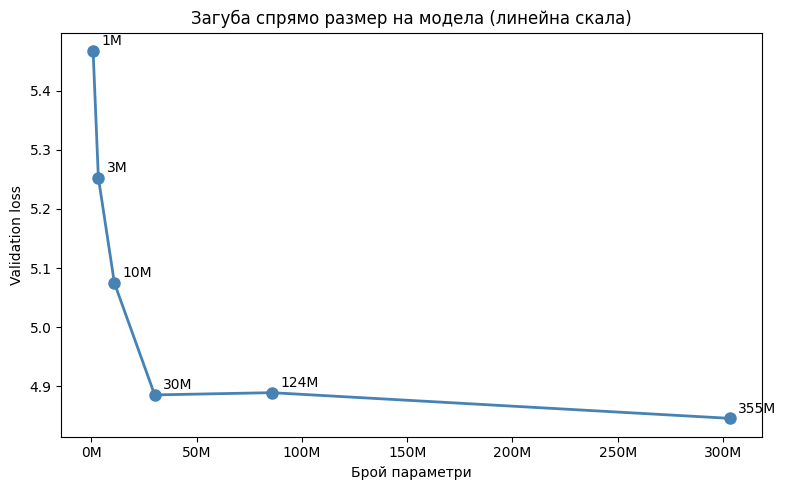

In [4]:
# За графиките използваме опростен DataFrame само с параметри и загуба
plot_df = df[["модел", "параметри", "val loss"]].copy()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(plot_df["параметри"], plot_df["val loss"], "o-", color="steelblue", linewidth=2, markersize=8)
for _, row in plot_df.iterrows():
    ax.annotate(row["модел"], (row["параметри"], row["val loss"]),
                textcoords="offset points", xytext=(6, 4), fontsize=10)

ax.set_xlabel("Брой параметри")
ax.set_ylabel("Validation loss")
ax.set_title("Загуба спрямо размер на модела (линейна скала)")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout()
plt.show()

На линейна скала кривата изглежда нередовна — подобрението се забавя бързо. Нека опитаме **log-log скала**.

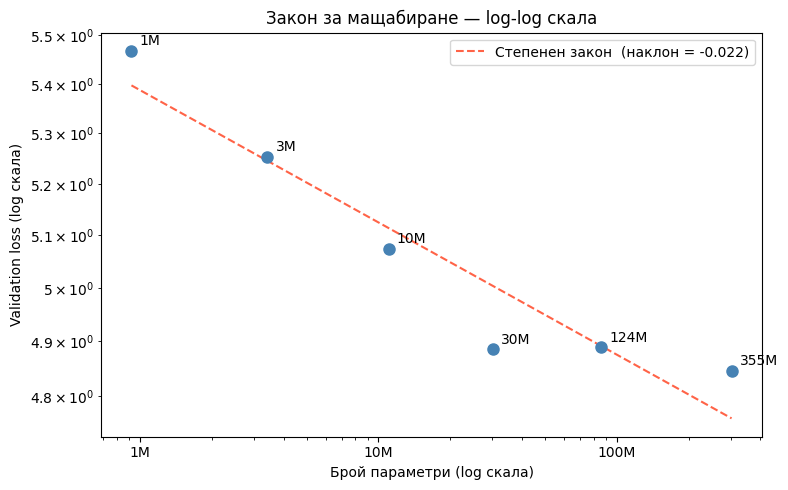

Наклон на степенния закон: -0.0217
Kaplan et al. намират наклон около -0.076 при GPT-3 мащаб


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(plot_df["параметри"], plot_df["val loss"], "o", color="steelblue", markersize=8, zorder=3)
for _, row in plot_df.iterrows():
    ax.annotate(row["модел"], (row["параметри"], row["val loss"]),
                textcoords="offset points", xytext=(6, 4), fontsize=10)

# Power law fit: log(L) = a * log(N) + b
log_params = np.log10(plot_df["параметри"].values)
log_loss   = np.log10(plot_df["val loss"].values)
a, b = np.polyfit(log_params, log_loss, 1)

x_fit = np.logspace(log_params.min(), log_params.max(), 100)
y_fit = 10 ** (a * np.log10(x_fit) + b)
ax.plot(x_fit, y_fit, "--", color="tomato", linewidth=1.5,
        label=f"Степенен закон  (наклон = {a:.3f})")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Брой параметри (log скала)")
ax.set_ylabel("Validation loss (log скала)")
ax.set_title("Закон за мащабиране — log-log скала")
ax.legend()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

print(f"Наклон на степенния закон: {a:.4f}")
print(f"Kaplan et al. намират наклон около -0.076 при GPT-3 мащаб")

**Ключово наблюдение:** На log-log скала точките лежат приблизително на права линия. Това е степенен закон — същата закономерност, която Kaplan et al. намират при модели с милиарди параметри.

Нашите модели са милиони пъти по-малки, но *моделът* е същият.

## Блок 2: Криви на обучение [Демо]

**Цел:** Да видим как се променя загубата по време на обучение за всеки модел — не само крайния резултат.

In [6]:
logs = {}
for model in ["1M", "3M", "10M", "30M", "124M", "355M"]:
    logs[model] = pd.read_csv(f"scaling_results/log_{model}.csv")
    print(f"{model}: {len(logs[model])} eval точки, "
          f"финална val loss = {logs[model]['val_loss'].iloc[-1]:.4f}")

1M: 21 eval точки, финална val loss = 5.4693
3M: 21 eval точки, финална val loss = 5.2532
10M: 21 eval точки, финална val loss = 5.0746
30M: 21 eval точки, финална val loss = 4.8851
124M: 21 eval точки, финална val loss = 4.8892
355M: 21 eval точки, финална val loss = 4.8454


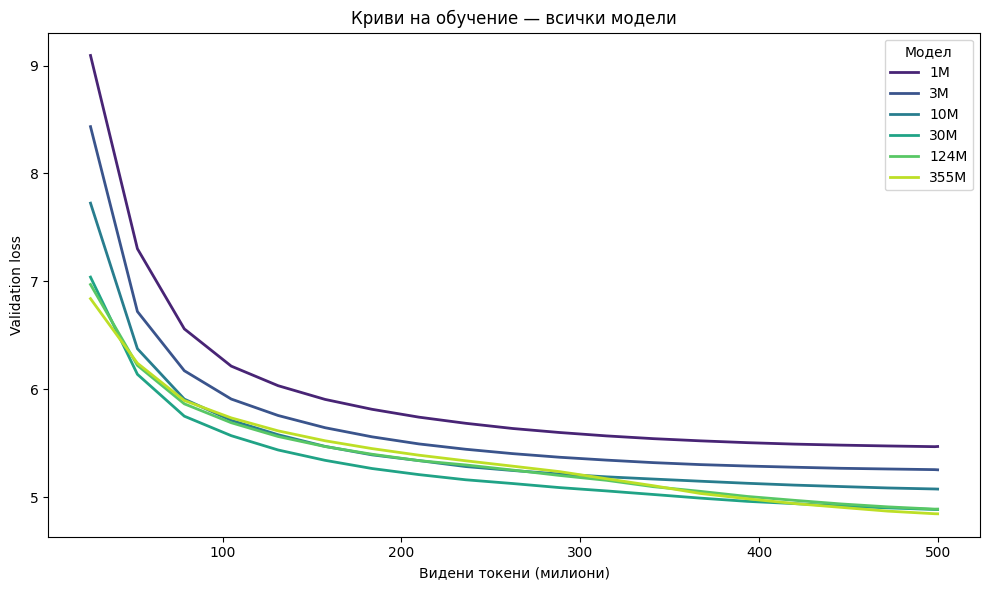

In [7]:
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 6))
fig, ax = plt.subplots(figsize=(10, 6))

for (model, log), color in zip(logs.items(), colors):
    log_clean = log[log["tokens_seen"] > 0]
    ax.plot(log_clean["tokens_seen"] / 1e6, log_clean["val_loss"],
            label=model, color=color, linewidth=2)

ax.set_xlabel("Видени токени (милиони)")
ax.set_ylabel("Validation loss")
ax.set_title("Криви на обучение — всички модели")
ax.legend(title="Модел")
plt.tight_layout()
plt.show()

## Блок 3: Връзка с по-голямата картина [Обяснение]

**Цел:** Да позиционираме нашите модели спрямо GPT-2, GPT-3 и LLaMA и да разберем какво предсказва степенният закон.

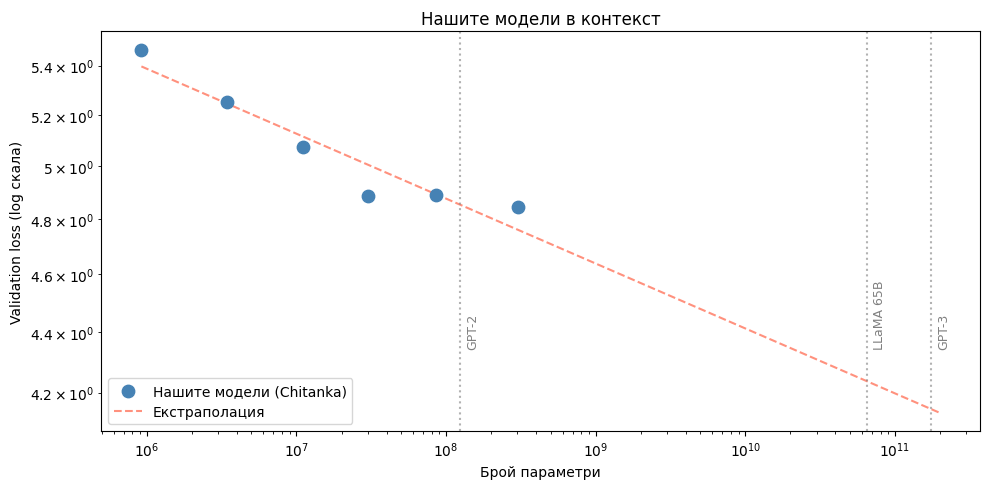

In [8]:
known_models = {
    "GPT-2":     124e6,
    "GPT-3":     175e9,
    "LLaMA 65B": 65e9,
}

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(plot_df["параметри"], plot_df["val loss"],
           color="steelblue", s=80, zorder=4, label="Нашите модели (Chitanka)")

x_ext = np.logspace(np.log10(plot_df["параметри"].min()), np.log10(200e9), 200)
y_ext = 10 ** (a * np.log10(x_ext) + b)
ax.plot(x_ext, y_ext, "--", color="tomato", linewidth=1.5, alpha=0.7, label="Екстраполация")

for name, params in known_models.items():
    ax.axvline(params, color="gray", linestyle=":", alpha=0.6)
    ax.text(params * 1.1, y_ext[-1] * 1.05, name,
            rotation=90, va="bottom", ha="left", fontsize=9, color="gray")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Брой параметри")
ax.set_ylabel("Validation loss (log скала)")
ax.set_title("Нашите модели в контекст")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
params = plot_df["параметри"].values
losses = plot_df["val loss"].values

print("Ефект от увеличение на параметрите:")
for i in range(len(plot_df) - 1):
    ratio = params[i+1] / params[i]
    drop  = losses[i] - losses[i+1]
    print(f"  {plot_df['модел'].iloc[i]:>4} → {plot_df['модел'].iloc[i+1]:<5}  "
          f"({ratio:.1f}x параметри)  →  загубата пада с {drop:.3f}")

Ефект от увеличение на параметрите:
    1M → 3M     (3.7x параметри)  →  загубата пада с 0.214
    3M → 10M    (3.2x параметри)  →  загубата пада с 0.179
   10M → 30M    (2.7x параметри)  →  загубата пада с 0.189
   30M → 124M   (2.8x параметри)  →  загубата пада с -0.004
  124M → 355M   (3.5x параметри)  →  загубата пада с 0.043


## Блок 4: Сравнение на изходи — 10M vs 355M [Демо]

**Цел:** Да видим конкретно какво "умее" по-голям модел — не само число за загубата, а реален генериран текст.

In [25]:
import sys, torch
from dataclasses import dataclass
from tokenizers import Tokenizer

sys.path.insert(0, ".")
from scaling_experiment import GPT, GPTConfig

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)

Устройство: cpu


In [26]:
def load_model(name):
    ckpt = torch.load(f"scaling_results/ckpt_{name}.pt", map_location=DEVICE, weights_only=False)
    config = GPTConfig(**ckpt["config"])
    model = GPT(config)
    state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}
    model.load_state_dict(state_dict)
    model.eval()
    model.to(DEVICE)
    print(f"{name}: {model.count_params():,} параметри, val loss = {ckpt['val_loss']:.4f}")
    return model

tokenizer = Tokenizer.from_file("tokenizer/tokenizer.json")
model_10m  = load_model("10M")
model_355m = load_model("355M")

10M: 11,020,032 параметри, val loss = 5.0746
355M: 303,138,816 параметри, val loss = 4.8454


In [33]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=12, temperature=0.8, top_k=50):
    ids = tokenizer.encode(prompt).ids
    x = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    for _ in range(max_new_tokens):
        logits, _ = model(x[:, -model.config.block_size:])
        logits = logits[:, -1, :] / temperature
        # top-k filtering
        top_vals, _ = torch.topk(logits, top_k)
        logits[logits < top_vals[:, -1:]] = float("-inf")
        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_id], dim=1)
    return tokenizer.decode(x[0].tolist())

In [36]:
prompts = [
    "Иван е ",
]

for prompt in prompts:
    print(f"{'─'*60}")
    print(f"Prompt: {prompt!r}")
    print(f"\n  10M:  {generate(model_10m,  prompt)}")
    print(f"\n  355M: {generate(model_355m, prompt)}")
print(f"{'─'*60}")

────────────────────────────────────────────────────────────
Prompt: 'Иван е '

  10M:  Иван е .
	— Ти си?
	— Ще ви

  355M: Иван е фел, когато се чувстваше, че на Тамаър.
────────────────────────────────────────────────────────────


## Колко голям модел можем да обучим за 12 часа?

Използваме законите за мащабиране, за да отговорим на конкретен въпрос: при фиксиран изчислителен бюджет, кой е оптималният брой параметри и токени?

### 1. Изчислителен бюджет

RTX 5090 има теоретична производителност ~1 676 TFLOPS в BF16. При реален коефициент на използване ~40% (MFU) получаваме ефективно:

$$C_{\text{eff}} \approx 500 \text{ TFLOPS}$$

За 12 часа обучение:

$$C = 500 \times 10^{12} \times 12 \times 3600 \approx 2 \times 10^{19} \text{ FLOPs}$$

### 2. Оптимален размер (Chinchilla)

Hoffmann et al. (2022) показват, че при дадено изчислително количество C, оптималните N (параметри) и D (токени) са свързани с:

$$C = 6 \cdot N \cdot D$$

и Chinchilla съотношението $D_{\text{opt}} = 20 \cdot N_{\text{opt}}$, откъдето:

$$C = 6 \cdot N \cdot 20N = 120 \cdot N^2$$

Решаваме за N:

$$N_{\text{opt}} = \sqrt{\frac{C}{120}} = \sqrt{\frac{2 \times 10^{19}}{120}} \approx 400\text{M параметри}$$

$$D_{\text{opt}} = 20 \times 400\text{M} \approx 8\text{B токена}$$

### 3. Проблемът с данните

Корпусът от Chitanka съдържа ~420M токена — 20 пъти по-малко от необходимото. Повторното използване на едни и същи данни помага малко, но моделът започва да ги наизустява вместо да обобщава.

За да достигнем 8B токена на български, трябва да комбинираме източници:

| Източник | Приблизителен брой токени |
|----------|---------------------------|
| Chitanka | ~420M |
| OSCAR / CC-100 (български) | ~2–3B |
| mC4 (български) | ~3–5B |
| Wikipedia BG + новини | ~500M |
| **Общо** | **~6–9B** |

### 4. Практическа препоръка

При комбиниран корпус от ~8B токена и 12 часа на RTX 5090:

- **~300–400M параметри**, обучени на **~8B токена**
- Chinchilla съотношение D/N ≈ 20–25 (близо до оптималното)
- Резултатът би бил приблизително на нивото на GPT-2 за български — вероятно малко над него, тъй като архитектурата вече включва подобрения: без bias, weight tying, BF16 и cosine learning rate schedule

## Ресурси

- Kaplan et al. 2020 — "Scaling Laws for Neural Language Models"
- Hoffmann et al. 2022 — "Training Compute-Optimal Large Language Models" (Chinchilla)
- Brown et al. 2020 — "Language Models are Few-Shot Learners" (GPT-3)
- Wei et al. 2022 — "Emergent Abilities of Large Language Models"
- Schaeffer et al. 2023 — "Are Emergent Abilities of Large Language Models a Mirage?"